Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'modelzoo-figures' already exists and is not an empty directory.
Loading.... superanimal_quadruped


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(…)d_resnet_50_iteration-0_shuffle-1.tar.gz:   0%|          | 0.00/294M [00:00<?, ?B/s]

Loaded 2155 quadruped images from the ZIP file.
Loaded 10 animal face images.


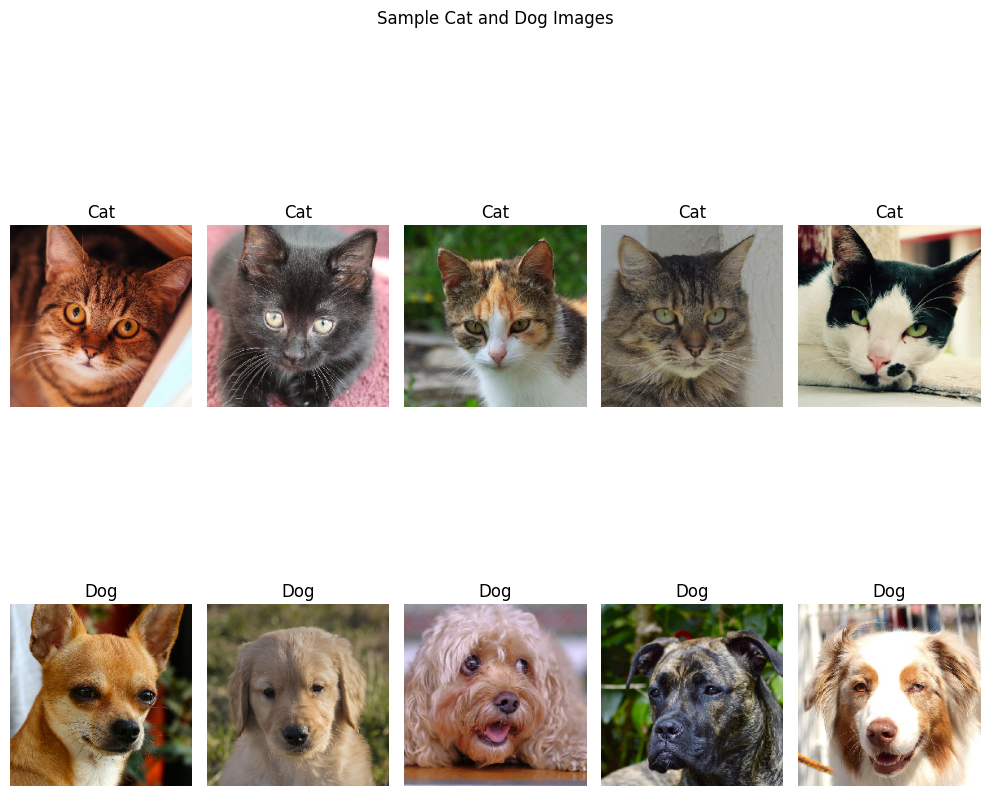

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 394272)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 200)                 │      78,854,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 200)                 │          40,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             402 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,896,098 (300.96 MB)

 Trainable params: 78,896,098 (300.96 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.7124 - val_accuracy: 0.2000 - val_loss: 4.7243
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 7.5321 - val_accuracy: 0.8000 - val_loss: 13.5572
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 23.9403 - val_accuracy: 0.8000 - val_loss: 4.7922
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8000 - loss: 1.3095 - val_accuracy: 0.7000 - val_loss: 3.8525
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9000 - loss: 0.9919 - val_accuracy: 0.4000 - val_loss: 9.2932
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.8000 - loss: 1.6156 - val_accuracy: 0.4000 - val_loss: 10.2307
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8000 - loss: 0.1801 - val_accuracy: 0.4000 - val_loss: 11.6136
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9000 - loss: 4.2427 - val_accuracy: 0.5000 - val_loss: 9.7790
Epoch 9/15
1

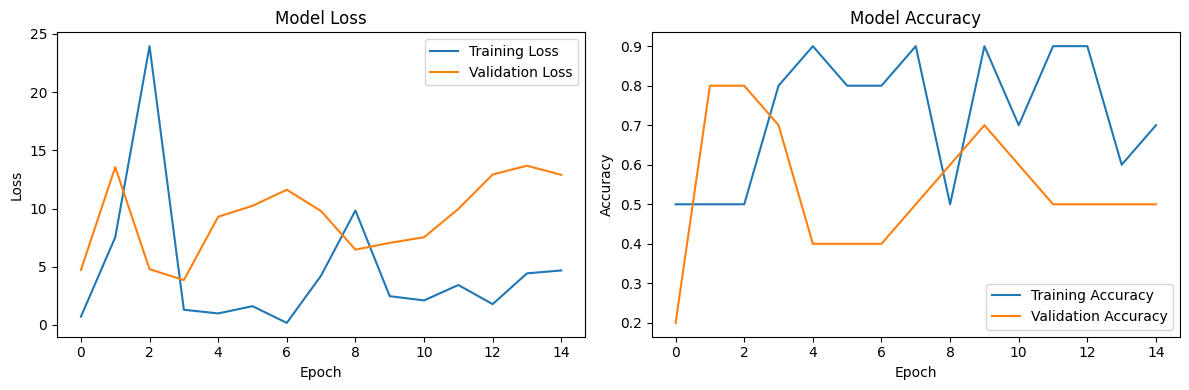

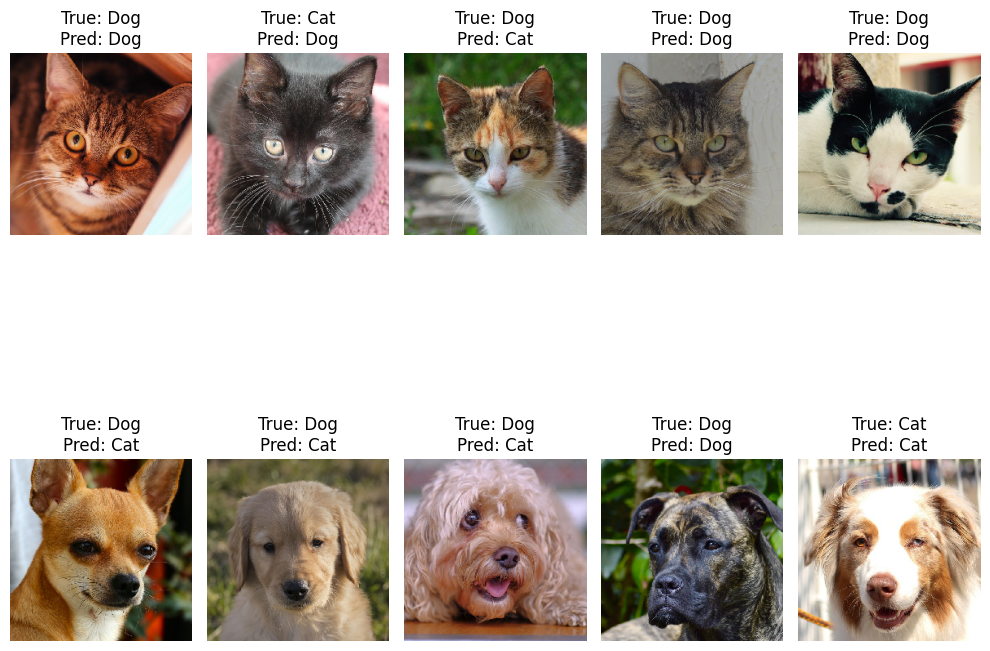

In [1]:
!pip install dlclibrary
from pathlib import Path
import os
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from keras import layers
from keras.models import Model
from keras.utils import to_categorical
from sklearn import metrics
from dlclibrary import download_huggingface_model
import zipfile
from PIL import Image

#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/AdaptiveMotorControlLab/modelzoo-figures.git
# Creates a folder and downloads model to it
model_dir = Path("./superanimal_quadruped_model_pytorch")
model_dir.mkdir(exist_ok=True)
download_huggingface_model("superanimal_quadruped", model_dir)

data_folder = Path("modelzoo-figures")
quadruped_animal_path = "/content/drive/MyDrive/Quadruped Animal Images.zip"

# Extract quadruped animal file
extracted_folder = Path("quadruped_animal_extracted")
with zipfile.ZipFile(quadruped_animal_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_folder)

# Load quadruped images from the extracted folder
def load_quadruped_images_from_folder(folder_path):
    images = []
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.endswith(".jpg") or filename.endswith(".png"):
                img_path = os.path.join(root, filename)
                img = Image.open(img_path)
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                img = img.resize((224, 224))
                img = np.array(img)
                images.append(img)
    return np.array(images)

# Load images from extracted ZIP file
quadruped_images = load_quadruped_images_from_folder(extracted_folder)
print(f"Loaded {len(quadruped_images)} quadruped images from the ZIP file.")

zip_file_path = "/content/drive/MyDrive/archive.zip"
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall("extracted_images")

# Load animal face images
def load_animal_face_images(data_folder, folders_to_use=["cat", "dog"], num_images_per_folder=10):
    images = []
    labels = []
    for folder_name in folders_to_use:
        folder_path = data_folder / folder_name
        image_count = 0
        for filename in os.listdir(folder_path):
            if filename.endswith(".jpg") or filename.endswith(".png"):
                img = load_img(folder_path / filename, target_size=(224, 224))
                img = img_to_array(img)
                images.append(img)
                labels.append(0 if folder_name == "cat" else 1)
                image_count += 1
                if image_count >= num_images_per_folder:
                    break
    return np.array(images), np.array(labels)

# Limit the amount of quadruped images
def load_quadruped_images_with_limit(data_folder, folders_to_use=["cats", "dogs"], num_images_per_folder=5):
    images = []
    labels = []
    for folder_name in folders_to_use:
        folder_path = data_folder / folder_name
        image_count = 0
        for filename in os.listdir(folder_path):
            if filename.endswith(".jpg") or filename.endswith(".png"):
                img = load_img(folder_path / filename, target_size=(224, 224))
                img = img_to_array(img)
                images.append(img)
                labels.append(0 if folder_name == "cats" else 1)
                image_count += 1
                if image_count >= num_images_per_folder:
                    break
    return np.array(images), np.array(labels)

# Limit is 5 images for cat and dog
limited_animal_face_images, limited_labels = load_quadruped_images_with_limit(
    Path("extracted_images"),
    folders_to_use=["cat", "dog"],
    num_images_per_folder=5
)

# Data normalization
limited_animal_face_images = limited_animal_face_images.astype('float32') / 255.0

# Apply limit function to quadruped images
quadruped_images = limited_animal_face_images

animal_face_images, labels = load_animal_face_images(Path("extracted_images"), num_images_per_folder=5)
print(f"Loaded {len(animal_face_images)} animal face images.")

# Normalize face images
animal_face_images = animal_face_images.astype('float32') / 255.0

# Seperate cat and dog images for visualization
cat_images = animal_face_images[labels == 0][:5]
dog_images = animal_face_images[labels == 1][:5]
cat_labels = labels[labels == 0][:5]
dog_labels = labels[labels == 1][:5]

combined_images = np.concatenate((cat_images, dog_images), axis=0)
combined_labels = np.concatenate((cat_labels, dog_labels), axis=0)

def show_images_with_labels(images, labels, title):
    """Displays images in a grid with their labels."""
    plt.figure(figsize=(10, 10))
    for i in range(len(images)):
        plt.subplot(2, 5, i + 1)
        img = images[i] * 255.0 if images[i].max() <= 1.0 else images[i]
        plt.imshow(img.astype("uint8"))
        plt.title("Cat" if labels[i] == 0 else "Dog")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images_with_labels(combined_images, combined_labels, "Sample Cat and Dog Images")

# Load images with minimum samples
min_samples = min(len(quadruped_images), len(animal_face_images))
quadruped_images = quadruped_images[:min_samples]
animal_face_images = animal_face_images[:min_samples]

# Create labels (Cat = 0, Dog = 1)
y_train = np.random.randint(0, 2, min_samples)
y_test = np.random.randint(0, 2, min_samples)

y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

# classify qadruped images based on prediction labels
pose_input = layers.Input(shape=(224, 224, 3))
x1 = layers.Conv2D(32, (3, 3), activation='relu')(pose_input)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Flatten()(x1)

# Define the model for prediction
x = layers.Dense(200, activation='relu')(x1)
x = layers.Dropout(0.5)(x)
x = layers.Dense(200, activation='relu')(x)
x = layers.Dense(2, activation='softmax')(x)

# Create the model
model = Model(inputs=pose_input, outputs=x)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(
    quadruped_images,
    y_train,
    batch_size=32,
    epochs=15,
    validation_data=(quadruped_images, y_test)
)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(quadruped_images, y_test)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

predictions = model.predict(quadruped_images)

predicted_classes = np.argmax(predictions, axis=1)

# Display the predicted class labels
for i in range(len(predicted_classes)):
    print(f"Image {i}: Predicted Class: {'Cat' if predicted_classes[i] == 0 else 'Dog'}")

# Visualize some predictions
def show_predictions_with_labels(images, predicted_labels, true_labels):
    """Displays images in a grid with their true and predicted labels."""
    plt.figure(figsize=(10, 10))
    for i in range(len(images)):
        plt.subplot(2, 5, i + 1)
        img = images[i] * 255.0 if images[i].max() <= 1.0 else images[i]
        plt.imshow(img.astype("uint8"))
        plt.title(f"True: {'Cat' if true_labels[i] == 0 else 'Dog'}\nPred: {'Cat' if predicted_labels[i] == 0 else 'Dog'}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
# Display predictions for the test set
show_predictions_with_labels(quadruped_images, predicted_classes, np.argmax(y_test, axis=1))


In [27]:
available_models = dlc.get_available_models('superanimal_quadruped')
print(available_models)  # Debugging step to see what it returns


['hrnet_w32', 'resnet_50']


In [9]:
from dlclibrary.dlcmodelzoo.modelzoo_download import test_

ImportError: cannot import name 'test_model' from 'dlclibrary.dlcmodelzoo.modelzoo_download' (/usr/local/lib/python3.10/dist-packages/dlclibrary/dlcmodelzoo/modelzoo_download.py)

In [32]:
from huggingface_hub import hf_hub_download, login

# Log in to your Hugging Face account
login() # you will be prompted to enter your token

# ... (rest of your code)

# Download the model with token authentication
model_path = hf_hub_download(
    repo_id="DeepLabCut/superanimal_quadruped",
    filename="resnet_50.pth",
    use_auth_token=True  # This ensures your token is used for the request
)

RepositoryNotFoundError: 404 Client Error. (Request ID: Root=1-674fc28c-01a4de0d48d6ff94787107b2;4bce92b4-70bc-42ed-ad4b-6b421a421c3c)

Repository Not Found for url: https://huggingface.co/DeepLabCut/superanimal_quadruped/resolve/main/resnet_50.pth.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated.

In [18]:
import dlclibrary as dlc

test_model = dlc.get_available_models('superanimal_quadruped')

In [4]:
!pip install transformers torch